In [1]:
# Run this once to get the tools
!pip install neonutilities h5py matplotlib pandas
import os
import neonutilities as nu
import h5py
import matplotlib.pyplot as plt
import glob

# Create a folder to store the data
output_dir = 'neon_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
print("Setup complete.")

   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   --- ------------------------------------ 0.5/6.3 MB 1.4 MB/s eta 0:00:05
   ---- ----------------------------------- 0.8/6.3 MB 1.5 MB/s eta 0:00:04
   ------ --------------------------------- 1.0/6.3 MB 1.5 MB/s eta 0:00:04
   -------- ------------------------------- 1.3/6.3 MB 1.5 MB/s eta 0:00:04
   --------- ------------------------------ 1.6/6.3 MB 1.4 MB/s eta 0:00:04
   ------------- -------------------------- 2.1/6.3 MB 1.6 MB/s eta 0:00:03
   ---------------- ----------------------- 2.6/6.3 MB 1.7 MB/s eta 0:00:03
   ------------------- -------------------- 3.1/6.3 MB 1.8 MB/s eta 0:00:02
   ------------------------ --------------- 3.9/6.3 MB 1.9 MB/s eta 0:00:02
   ---------------------------- ----------- 4.5/6.3 MB 2.0 MB/s eta 0:00:01
   ------------------------------- -------- 5.0/6.3 MB 2.0 MB/s eta 0:00:01
   -----------------------

In [7]:
import neonutilities as nu

# Let's try a different site/year combination just to test if it works
# This is a known, well-populated site (Harvard Forest)
nu.by_tile_aop(
    dpid='DP3.30006.001', 
    site='HARV', 
    year='2019', 
    easting=730000, 
    northing=4713000, 
    savepath='neon_data'
)

Provisional NEON data are not included. To download provisional data, use input parameter include_provisional=True.


Continuing will download 2 NEON data files totaling approximately 542.5 MB. Do you want to proceed? (y/n)  y



100%|████████████████████████████████████████████████████████████████████████████████████| 2/2 [02:38<00:00, 79.25s/it]


In [8]:
import os
# Walk through the directory to see everything inside
for root, dirs, files in os.walk('neon_data'):
    for file in files:
        if file.endswith('.h5'):
            print(f"FOUND IT: {os.path.join(root, file)}")

FOUND IT: neon_data\DP3.30006.001\neon-aop-products\2019\FullSite\D01\2019_HARV_6\L3\Spectrometer\Reflectance\NEON_D01_HARV_DP3_730000_4713000_reflectance.h5


In [14]:
import h5py

# Use your file_path variable from before
with h5py.File(file_path, 'r') as f:
    def print_structure(name, obj):
        print(name)
        
    f.visititems(print_structure)

HARV
HARV/Reflectance
HARV/Reflectance/Metadata
HARV/Reflectance/Metadata/Ancillary_Imagery
HARV/Reflectance/Metadata/Ancillary_Imagery/Aerosol_Optical_Depth
HARV/Reflectance/Metadata/Ancillary_Imagery/Aspect
HARV/Reflectance/Metadata/Ancillary_Imagery/Cast_Shadow
HARV/Reflectance/Metadata/Ancillary_Imagery/Dark_Dense_Vegetation_Classification
HARV/Reflectance/Metadata/Ancillary_Imagery/Data_Selection_Index
HARV/Reflectance/Metadata/Ancillary_Imagery/Haze_Cloud_Water_Map
HARV/Reflectance/Metadata/Ancillary_Imagery/Illumination_Factor
HARV/Reflectance/Metadata/Ancillary_Imagery/Path_Length
HARV/Reflectance/Metadata/Ancillary_Imagery/Sky_View_Factor
HARV/Reflectance/Metadata/Ancillary_Imagery/Slope
HARV/Reflectance/Metadata/Ancillary_Imagery/Smooth_Surface_Elevation
HARV/Reflectance/Metadata/Ancillary_Imagery/Visibility_Index_Map
HARV/Reflectance/Metadata/Ancillary_Imagery/Water_Vapor_Column
HARV/Reflectance/Metadata/Ancillary_Imagery/Weather_Quality_Indicator
HARV/Reflectance/Metadata/C

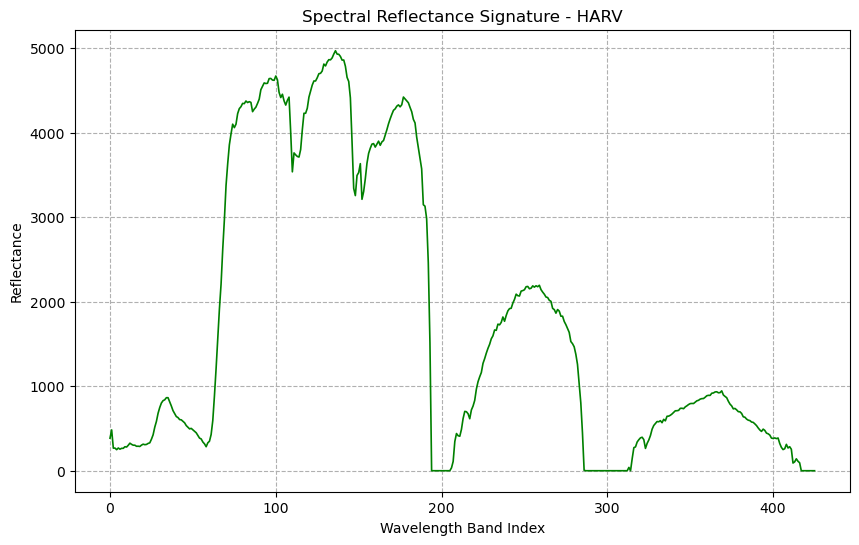

In [3]:
import h5py
import matplotlib.pyplot as plt

# 1. Open the file safely using the 'with' statement
with h5py.File(r'neon_data\DP3.30006.001\neon-aop-products\2019\FullSite\D01\2019_HARV_6\L3\Spectrometer\Reflectance\NEON_D01_HARV_DP3_730000_4713000_reflectance.h5', 'r') as f:
    # 2. Access the dataset object directly
    # We use the full path you confirmed earlier
    dataset = f['HARV/Reflectance/Reflectance_Data']
    
    # 3. Read the data into a numpy array
    refl = dataset[...]
    
    # 4. Extract the spectrum for one pixel (row 10, col 10)
    pixel_spectrum = refl[10, 10, :]

# 5. Plot the graph (outside the 'with' block, so the file is closed)
plt.figure(figsize=(10, 6))
plt.plot(pixel_spectrum, color='green', linewidth=1.2)
plt.title("Spectral Reflectance Signature - HARV")
plt.xlabel("Wavelength Band Index")
plt.ylabel("Reflectance")
plt.grid(True, linestyle='--')
plt.show()